In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

try:
    life_region_df = life_with_region.copy()
    print("Using existing variable: life_with_region")
except NameError:
    life_region_df = pd.read_csv("/Users/tonytony/Final Project/Data/Cleaned/life_with_wb_region.csv")
    print("Loaded file: life_with_wb_region.csv")

print("Shape:", life_region_df.shape)
life_region_df.head()


Loaded file: life_with_wb_region.csv
Shape: (266, 75)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2021,2022,2023,2024,Unnamed: 69,WB Region,Admin Region,Income Level,Lending Type,Country Type
0,Aruba,ABW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,64.049000,64.215000,64.602000,64.944000,65.303000,65.615000,...,73.655000,76.226000,76.353000,NaN,NaN,Latin America & Caribbean,NaN,High income,Not classified,Country/Territory
1,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,44.169658,44.468838,44.877890,45.160583,45.535695,45.770723,...,62.979999,64.487020,65.146154,NaN,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,32.799000,33.291000,33.757000,34.201000,34.673000,35.124000,...,60.417000,65.617000,66.035000,NaN,NaN,"Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Country/Territory
3,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.779636,38.058956,38.681792,38.936918,39.194580,39.479784,...,57.362572,57.987813,58.855722,NaN,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
4,Angola,AGO,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.933000,36.902000,37.168000,37.419000,37.704000,37.968000,...,62.958000,64.246000,64.617000,NaN,NaN,Sub-Saharan Africa,Sub-Saharan Africa (excluding high income),Lower middle income,IBRD,Country/Territory


In [2]:
if "Country Type" not in life_region_df.columns:
    life_region_df["Country Type"] = life_region_df["WB Region"].apply(
        lambda x: "Aggregate" if str(x).strip() == "Aggregates" else "Country/Territory"
    )

year_cols = [col for col in life_region_df.columns if str(col).isdigit()]
life_region_df[year_cols] = life_region_df[year_cols].apply(pd.to_numeric, errors="coerce")

life_long = life_region_df.melt(
    id_vars=["Country Name", "Country Code", "WB Region", "Country Type"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Life expectancy at birth, total (years)"
)

life_long["Year"] = pd.to_numeric(life_long["Year"], errors="coerce").astype("Int64")
life_long["Life expectancy at birth, total (years)"] = pd.to_numeric(
    life_long["Life expectancy at birth, total (years)"],
    errors="coerce"
)

life_long = life_long[
    (life_long["Country Type"] == "Country/Territory") &
    (life_long["WB Region"].notna()) &
    (life_long["Life expectancy at birth, total (years)"].notna())
].copy()

print("Long-format Life Expectancy dataset shape:", life_long.shape)
print("Year range:", int(life_long["Year"].min()), "-", int(life_long["Year"].max()))
print("Number of countries/territories:", life_long["Country Code"].nunique())

life_long.head()


Long-format Life Expectancy dataset shape: (13854, 6)
Year range: 1960 - 2023
Number of countries/territories: 217


,Country Name,Country Code,WB Region,Country Type,Year,"Life expectancy at birth, total (years)"
0,Aruba,ABW,Latin America & Caribbean,Country/Territory,1960,64.049
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory,1960,32.799
4,Angola,AGO,Sub-Saharan Africa,Country/Territory,1960,37.933
5,Albania,ALB,Europe & Central Asia,Country/Territory,1960,56.413
6,Andorra,AND,Europe & Central Asia,Country/Territory,1960,72.094


In [3]:
life_global_trend = (
    life_long
    .groupby("Year")
    .agg(
        country_count=("Country Code", "nunique"),
        mean_life_expectancy=("Life expectancy at birth, total (years)", "mean"),
        median_life_expectancy=("Life expectancy at birth, total (years)", "median"),
        min_life_expectancy=("Life expectancy at birth, total (years)", "min"),
        max_life_expectancy=("Life expectancy at birth, total (years)", "max")
    )
    .reset_index()
)

life_region_trend = (
    life_long
    .groupby(["WB Region", "Year"])
    .agg(
        country_count=("Country Code", "nunique"),
        mean_life_expectancy=("Life expectancy at birth, total (years)", "mean"),
        median_life_expectancy=("Life expectancy at birth, total (years)", "median"),
        min_life_expectancy=("Life expectancy at birth, total (years)", "min"),
        max_life_expectancy=("Life expectancy at birth, total (years)", "max")
    )
    .reset_index()
    .sort_values(["WB Region", "Year"])
)

print("Global trend shape:", life_global_trend.shape)
print("Regional trend shape:", life_region_trend.shape)

life_global_trend.head()


Global trend shape: (64, 6)
Regional trend shape: (448, 7)


,Year,country_count,mean_life_expectancy,median_life_expectancy,min_life_expectancy,max_life_expectancy
0,1960,215,54.904278,56.5390,28.054,74.040073
1,1961,216,55.441982,57.1450,28.278,73.652683
2,1962,216,55.885327,57.7765,28.506,73.721951
3,1963,215,56.194818,58.0990,28.249,73.586000
4,1964,215,56.695426,58.1700,31.231,73.855927


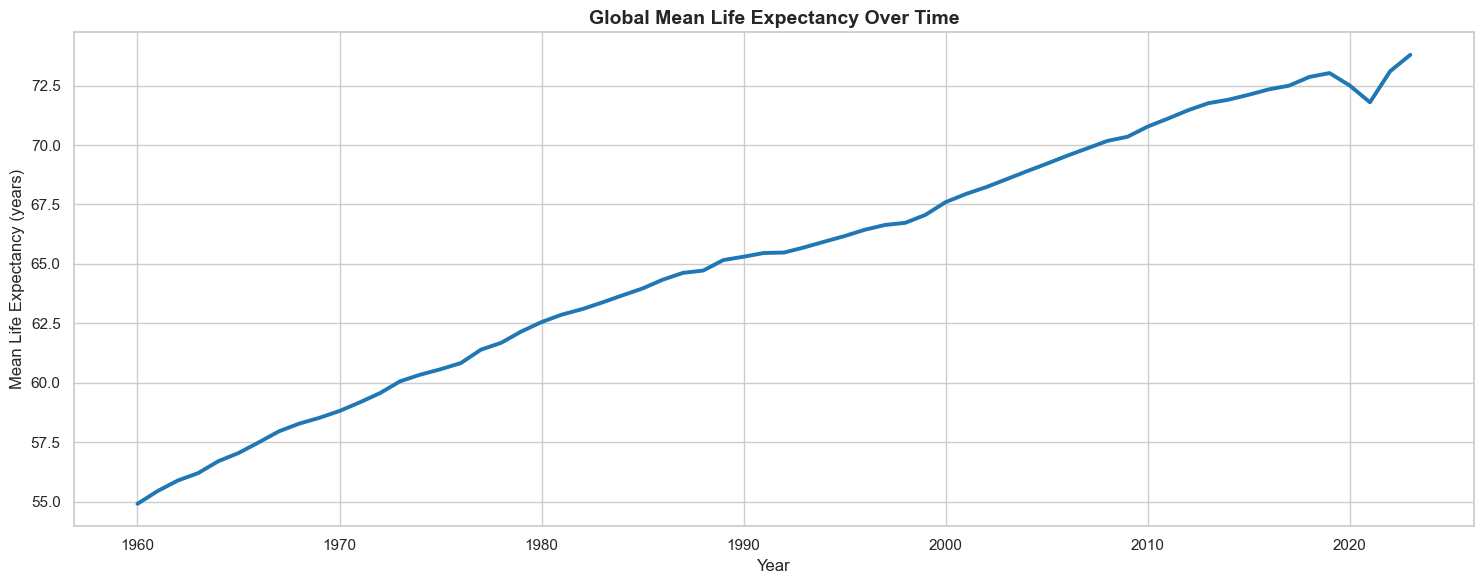

In [4]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=life_global_trend,
    x="Year",
    y="mean_life_expectancy",
    linewidth=2.8,
    color="#1f77b4"
)

plt.title("Global Mean Life Expectancy Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Mean Life Expectancy (years)")
plt.tight_layout()
plt.show()


### Insight - Global Mean Life Expectancy

The chart shows a long-term increase in average life expectancy around the world.

Key observations:
- The global mean generally rises over time, indicating overall improvement in health and living conditions.
- The upward pattern suggests that progress in healthcare, nutrition, sanitation, and public health has had a broad effect.
- Some short periods may show slower improvement or temporary disruptions, but the long-term direction remains positive.

Conclusion:
Global life expectancy has improved substantially over time, making it a strong indicator of progress in human development.


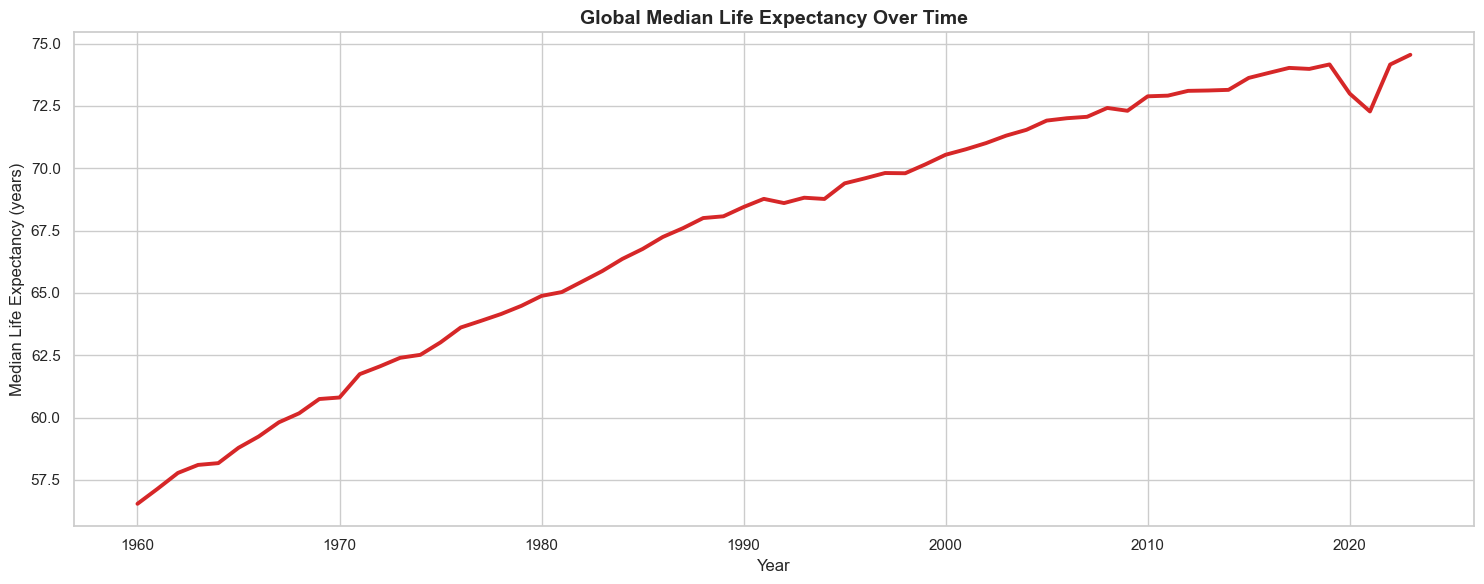

In [5]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=life_global_trend,
    x="Year",
    y="median_life_expectancy",
    linewidth=2.8,
    color="#d62728"
)

plt.title("Global Median Life Expectancy Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median Life Expectancy (years)")
plt.tight_layout()
plt.show()


### Insight - Global Median Life Expectancy

The median trend confirms that the typical country also experiences improvement in life expectancy.

Key observations:
- The median life expectancy increases over time in a pattern similar to the mean.
- The distance between the mean and median is usually smaller than in GDP analysis, which suggests a more compact distribution.
- This indicates that life expectancy improvements are not limited to a few countries only.

Conclusion:
The median supports the idea that gains in life expectancy are broad and widely shared across countries.


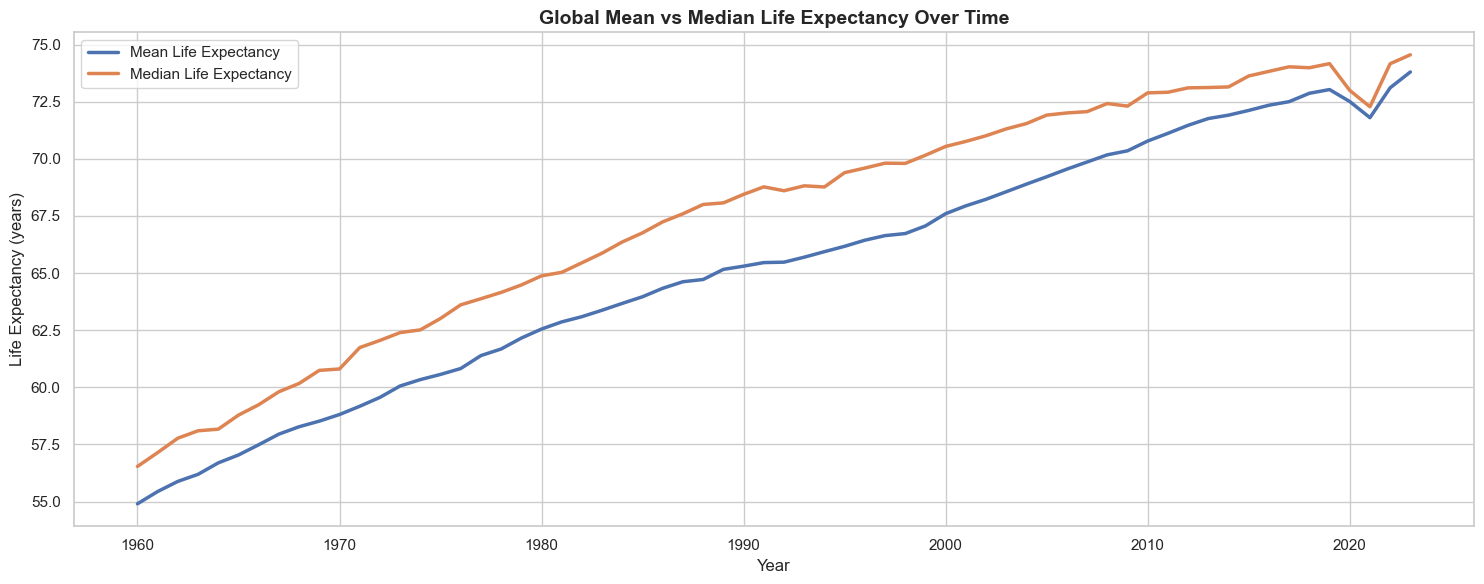

In [6]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=life_global_trend,
    x="Year",
    y="mean_life_expectancy",
    linewidth=2.5,
    label="Mean Life Expectancy"
)

sns.lineplot(
    data=life_global_trend,
    x="Year",
    y="median_life_expectancy",
    linewidth=2.5,
    label="Median Life Expectancy"
)

plt.title("Global Mean vs Median Life Expectancy Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.legend()
plt.tight_layout()
plt.show()


### Insight - Mean vs Median Life Expectancy

This chart helps evaluate the overall distribution of life expectancy.

Key observations:
- The mean and median are relatively close to each other.
- This suggests that life expectancy is less skewed than GDP or population.
- The closeness of the two lines indicates that extreme outliers have less impact on the global distribution.

Conclusion:
Life expectancy is more evenly distributed across countries than GDP per capita, which makes both mean and median reliable summary measures.


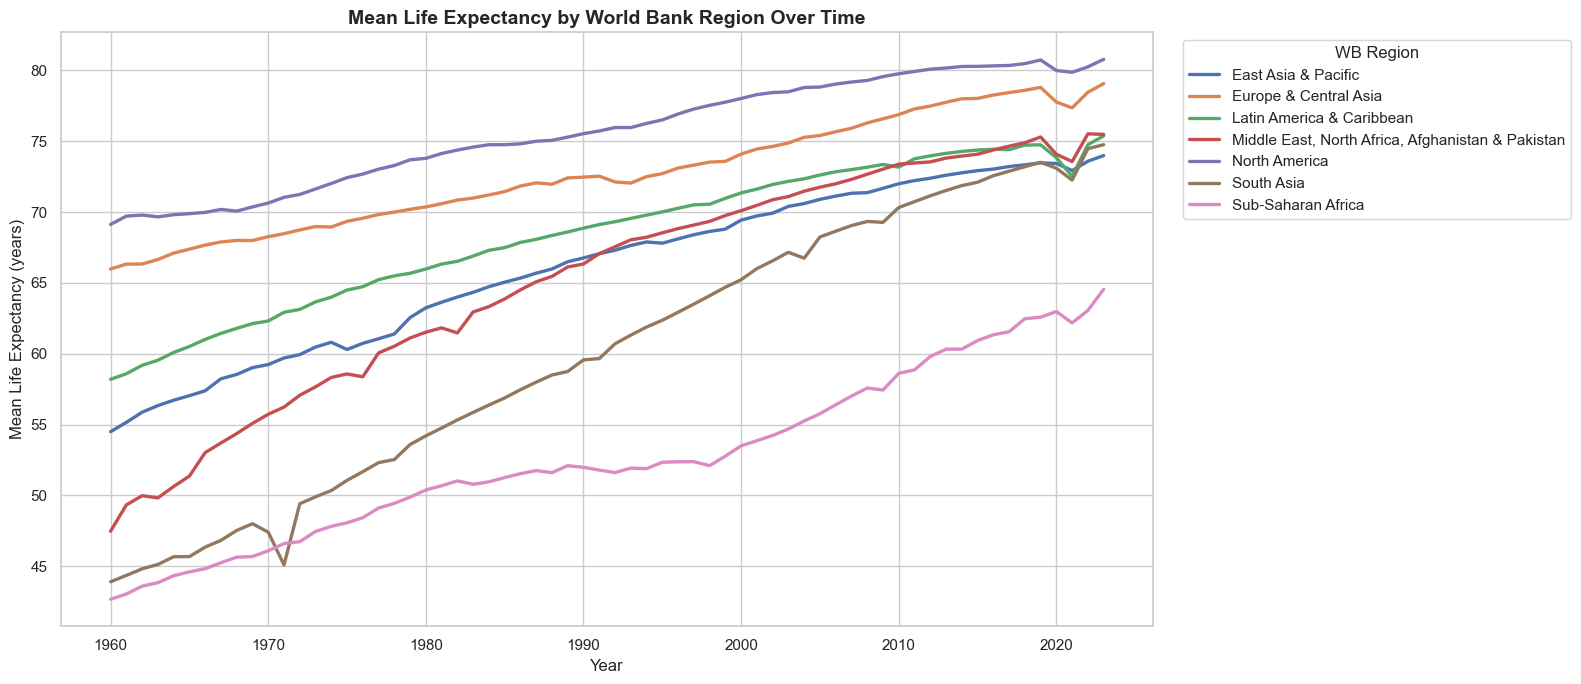

In [7]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=life_region_trend,
    x="Year",
    y="mean_life_expectancy",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Mean Life Expectancy by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Mean Life Expectancy (years)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Mean Life Expectancy by World Bank Region

This chart shows regional differences in health outcomes over time.

Key observations:
- Most regions show a long-term increase in average life expectancy.
- Higher-performing regions remain above others for most of the observed period.
- Lower-performing regions may improve substantially over time, but gaps between regions can still remain visible.

Conclusion:
Life expectancy improves in most regions, but progress is not uniform. Regional inequality in health outcomes still exists.


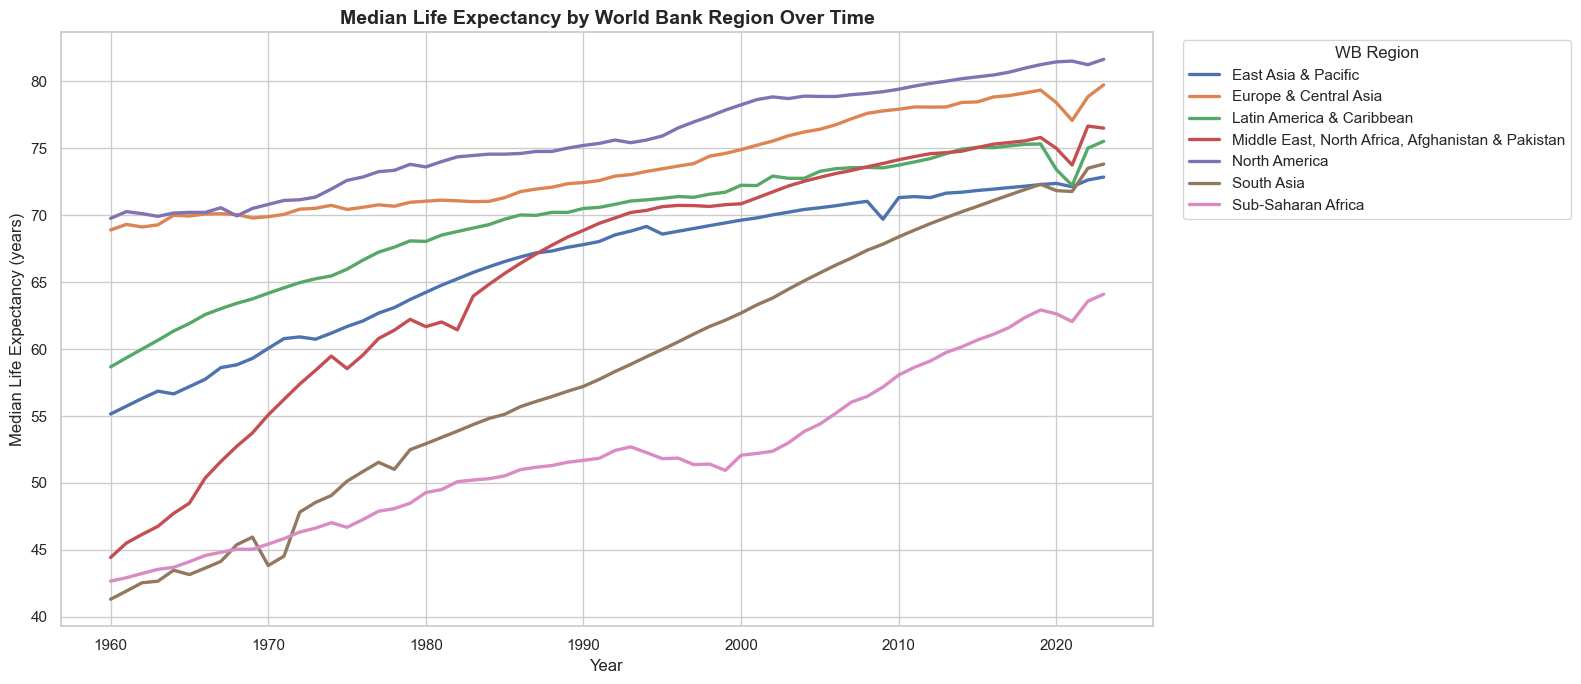

In [8]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=life_region_trend,
    x="Year",
    y="median_life_expectancy",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Median Life Expectancy by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median Life Expectancy (years)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Median Life Expectancy by World Bank Region

This chart gives a more typical regional view of life expectancy.

Key observations:
- Median regional trends are usually smooth and clearly upward.
- The median confirms that improvements are not driven only by a few exceptional countries.
- Regional differences remain visible, but the chart often shows a more stable pattern than the mean chart.

Conclusion:
The median life expectancy chart supports the finding that health outcomes improve over time in a broad and region-wide way.


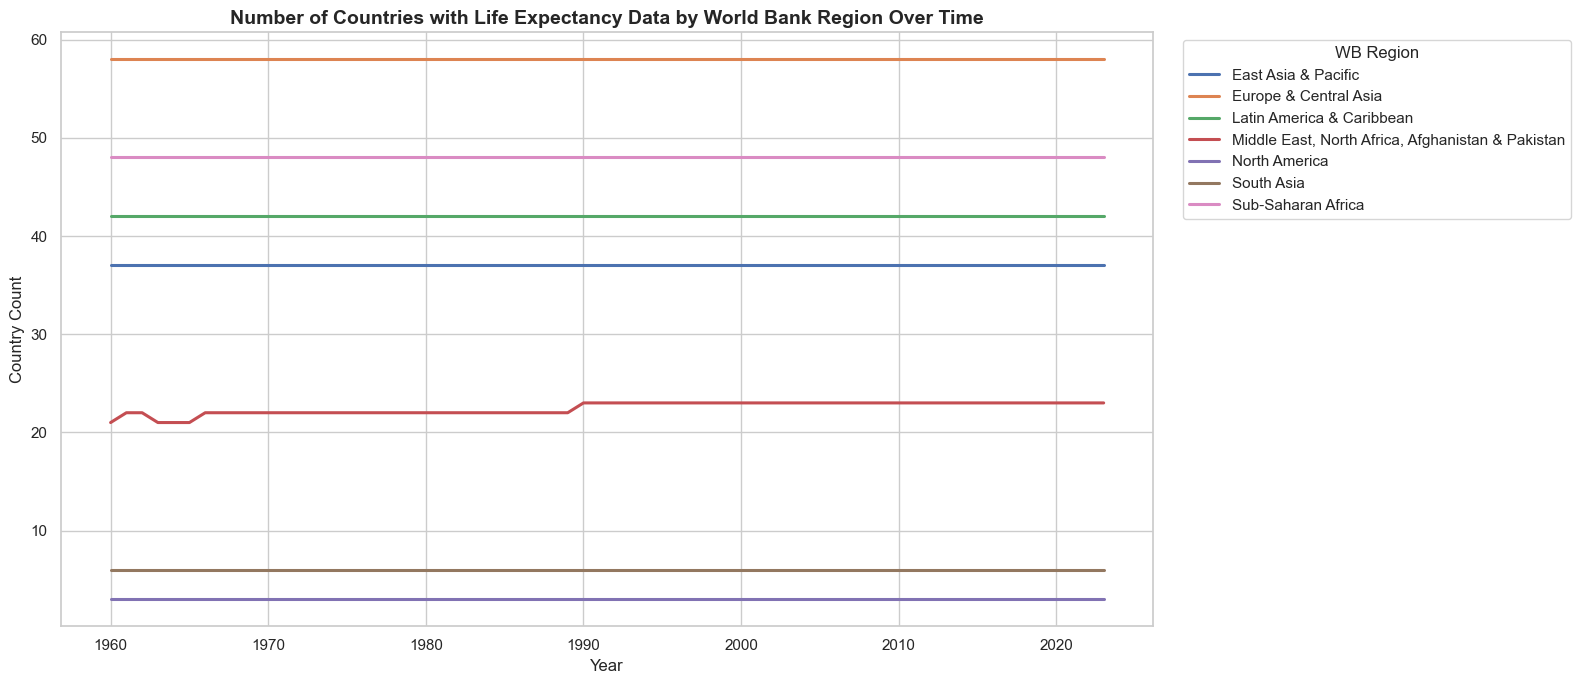

In [9]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=life_region_trend,
    x="Year",
    y="country_count",
    hue="WB Region",
    linewidth=2.2
)

plt.title("Number of Countries with Life Expectancy Data by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Country Count")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Data Coverage by Region

This chart helps assess the reliability of the regional time series.

Key observations:
- Coverage is generally strong across most years.
- Small differences in country count may still exist across regions.
- The final year should be checked carefully because the life expectancy dataset does not have usable 2024 values.

Conclusion:
Life expectancy coverage is generally good, but the latest usable year should be identified carefully before making final comparisons.


In [10]:
latest_year = int(life_region_trend["Year"].max())

life_latest_region = (
    life_region_trend[life_region_trend["Year"] == latest_year]
    .sort_values("mean_life_expectancy", ascending=False)
    .reset_index(drop=True)
)

print("Latest year:", latest_year)
life_latest_region


Latest year: 2023


,WB Region,Year,country_count,mean_life_expectancy,median_life_expectancy,min_life_expectancy,max_life_expectancy
0,North America,2023,3,80.780317,81.646585,78.385366,82.309000
1,Europe & Central Asia,2023,58,79.068492,79.740024,70.073000,86.372000
2,"Middle East, North Africa, Afghanistan & Pakistan",2023,23,75.484054,76.508000,65.170000,83.507317
3,Latin America & Caribbean,2023,42,75.375274,75.526500,64.936000,81.690000
4,South Asia,2023,6,74.754667,73.823500,70.354000,81.041000
5,East Asia & Pacific,2023,37,73.988972,72.852000,62.109000,85.247317
6,Sub-Saharan Africa,2023,48,64.547890,64.104000,54.462000,76.059000


In [11]:
highest_region = life_latest_region.iloc[0]
lowest_region = life_latest_region.iloc[-1]

print(f"Latest year in the dataset: {latest_year}")
print(f"Highest mean life expectancy region: {highest_region['WB Region']} ({highest_region['mean_life_expectancy']:.2f} years)")
print(f"Lowest mean life expectancy region: {lowest_region['WB Region']} ({lowest_region['mean_life_expectancy']:.2f} years)")
print("Interpretation note: 2024 is not used here because life expectancy values are not available for that year.")


Latest year in the dataset: 2023
Highest mean life expectancy region: North America (80.78 years)
Lowest mean life expectancy region: Sub-Saharan Africa  (64.55 years)
Interpretation note: 2024 is not used here because life expectancy values are not available for that year.
